In [ ]:
!pip install ultralytics -q
!pip install opencv-python-headless matplotlib numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00


In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO
from PIL import Image
import requests
from io import BytesIO
import os

print("All libraries imported successfully")
print(f" PyTorch version: {torch.__version__}")
print(f" GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f" GPU Name: {torch.cuda.get_device_name(0)}")

All libraries imported successfully
 PyTorch version: 2.10.0+cu128
 GPU Available: True
 GPU Name: Tesla T4


In [ ]:

model = YOLO('yolov8n.pt')

print(" YOLOv8 model loaded successfully!")
print(f" Model: YOLOv8n pretrained on COCO dataset")
print(f" Number of classes: {len(model.names)}")
print(f" Sample classes: {list(model.names.values())[:10]}")

 YOLOv8 model loaded successfully!
 Model: YOLOv8n pretrained on COCO dataset
 Number of classes: 80
 Sample classes: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


In [ ]:
def visualize_detections(image_input, results, title="Object Detection Results"):
    """
    Visualize bounding boxes and labels on detected objects.
    image_input: file path (str) or numpy array
    """

    if isinstance(image_input, str):
        img = cv2.imread(image_input)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    elif isinstance(image_input, np.ndarray):
        if len(image_input.shape) == 3 and image_input.shape[2] == 3:
            img_rgb = image_input
        else:
            img_rgb = cv2.cvtColor(image_input, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = np.array(image_input)

    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    ax.imshow(img_rgb)

    colors = plt.cm.get_cmap('tab20', 80)
    detection_count = 0

    for result in results:
        boxes = result.boxes
        if boxes is not None:
            for box in boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                conf = float(box.conf[0].cpu().numpy())
                cls_id = int(box.cls[0].cpu().numpy())
                cls_name = model.names[cls_id]

                if conf >= 0.4:
                    detection_count += 1
                    color = colors(cls_id / 80)

                    # Draw bounding box
                    rect = patches.Rectangle(
                        (x1, y1), x2 - x1, y2 - y1,
                        linewidth=2, edgecolor=color, facecolor='none'
                    )
                    ax.add_patch(rect)

                    # Draw label
                    label = f"{cls_name}: {conf:.2f}"
                    ax.text(
                        x1, y1 - 5, label,
                        fontsize=9, color='white',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.8)
                    )

    ax.set_title(f"{title} | Total Detections: {detection_count}", fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f" Detected {detection_count} objects")

print(" Visualization function ready")

 Visualization function ready


 Image size: (810, 1080)
 Running detection...


/tmp/ipykernel_1628/863815930.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', 80)


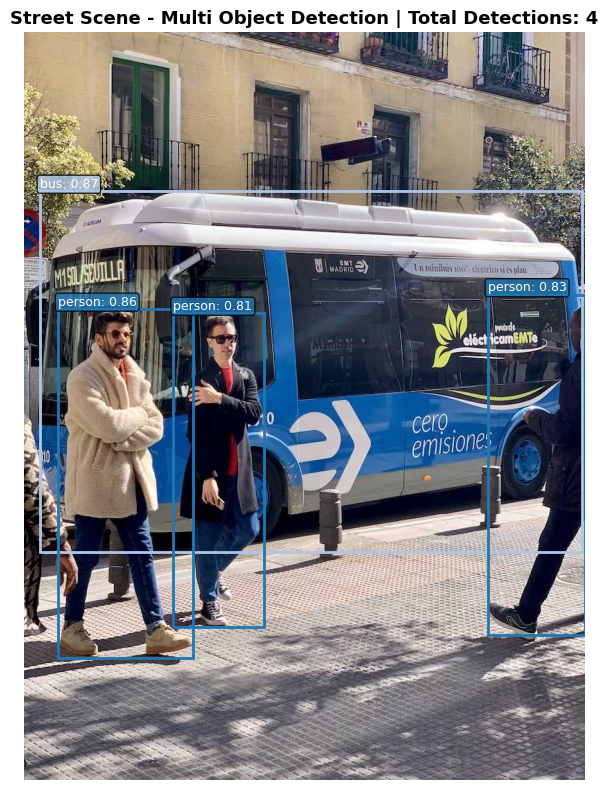

 Detected 4 objects

 Detection Summary:
----------------------------------------
 bus             | Conf: 0.87 | Box: [22,228,805,750]
 person          | Conf: 0.86 | Box: [48,399,243,902]
 person          | Conf: 0.83 | Box: [669,378,809,869]
 person          | Conf: 0.81 | Box: [215,405,346,858]


In [ ]:
def detect_from_url(image_url, title="URL Image Detection"):
    """Download an image from URL and run detection."""
    try:
        response = requests.get(image_url, timeout=10)
        img = Image.open(BytesIO(response.content)).convert("RGB")
        img_np = np.array(img)

        print(f" Image size: {img.size}")
        print(" Running detection...")

        results = model.predict(img_np, conf=0.4, iou=0.45, verbose=False)
        visualize_detections(img_np, results, title)


        print("\n Detection Summary:")
        print("-" * 40)
        for result in results:
            if result.boxes is not None:
                for box in result.boxes:
                    cls_id = int(box.cls[0])
                    conf = float(box.conf[0])
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    print(f" {model.names[cls_id]:<15} | Conf: {conf:.2f} | Box: [{int(x1)},{int(y1)},{int(x2)},{int(y2)}]")
    except Exception as e:
        print(f" Error: {e}")

detect_from_url(
    "https://ultralytics.com/images/bus.jpg",
    title="Street Scene - Multi Object Detection"
)

 Upload an image from your computer:


Saving Sample living room picture.jpg to Sample living room picture.jpg

 Running detection on: Sample living room picture.jpg


/tmp/ipykernel_1628/863815930.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', 80)


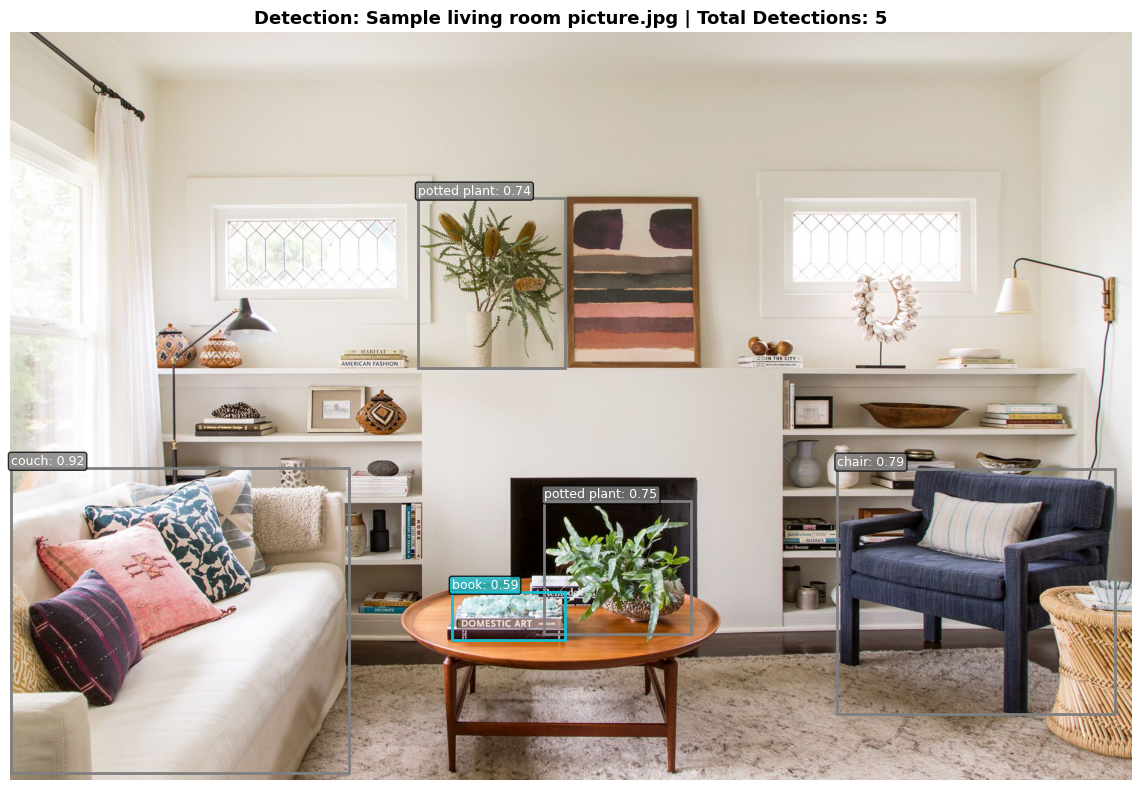

 Detected 5 objects

 Detection Summary:
----------------------------------------
    couch           | Confidence: 0.92
    chair           | Confidence: 0.79
    potted plant    | Confidence: 0.75
    potted plant    | Confidence: 0.74
    book            | Confidence: 0.59


In [ ]:
from google.colab import files

print(" Upload an image from your computer:")
uploaded = files.upload()

for filename, content in uploaded.items():
    # Save uploaded file
    with open(filename, 'wb') as f:
        f.write(content)

    print(f"\n Running detection on: {filename}")
    results = model.predict(filename, conf=0.4, iou=0.45, verbose=False)
    visualize_detections(filename, results, title=f"Detection: {filename}")

    # Summary
    print("\n Detection Summary:")
    print("-" * 40)
    for result in results:
        if result.boxes is not None:
            for box in result.boxes:
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                print(f"    {model.names[cls_id]:<15} | Confidence: {conf:.2f}")

In [ ]:
print("Evaluating model on COCO128 validation set...")
print(" This may take 2-3 minutes...\n")

metrics = model.val(data='coco128.yaml', verbose=False)

print("\n Evaluation Complete!")
print("=" * 45)
print(f" mAP@0.50       : {metrics.box.map50:.4f}")
print(f" mAP@0.50:0.95  : {metrics.box.map:.4f}")
print(f" Precision      : {metrics.box.mp:.4f}")
print(f" Recall         : {metrics.box.mr:.4f}")
print("=" * 45)
print("\n Metric Explanation:")
print("  mAP@0.50      → Accuracy at IoU threshold 0.5 (standard benchmark)")
print("  mAP@0.50:0.95 → Average accuracy across IoU thresholds (strict)")
print("  Precision     → Of all detected objects, how many were correct")
print("  Recall        → Of all real objects, how many were detected")

Evaluating model on COCO128 validation set...
 This may take 2-3 minutes...

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1580.0±486.0 MB/s, size: 46.9 KB)
val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 38.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.2it/s 3.6s
                   all        128        929      0.639      0.536      0.607      0.448
Speed: 4.9ms preprocess, 4.5ms inference, 0.0ms loss, 3.9ms postprocess per image
Results saved to /content/runs/detect/val2

 Evaluation Complete!
 mAP@0.50       : 0.6072
 mAP@0.50:0.95  : 0.4478
 Precision      : 0.6385
 Recall         : 0.5361

 Metric Explanation:
  mAP@0.50      → Accuracy at IoU threshold 0.5 (standard benchmark)
  mAP@0.50:0.95 → Average accuracy across IoU thresholds (